In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from sklearn.preprocessing import StandardScaler
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
class_param = pd.read_csv('../data/classification_parameters.csv')
reservoir_info = pd.read_csv('../data/reservoir_info.csv')
well_data = pd.read_csv('../data/spe_africa_dseats_datathon_2025_wells_dataset.csv')
sample_sub = pd.read_csv('../data/Innovisors_DSEATS_Africa_2025_Classification.csv')

In [3]:
sample_sub

,Well,Reservoir Name,Reservoir Type,Well Type,Production Type,Formation GOR Trend,Watercut Trend,Oil Productivity Index
0,1,KEMA,Saturated,GL,Unsteady,aSolGOR,Flat,Decr
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
reservoir_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Reservoir Name                            5 non-null      object 
 1   Initial Reservoir Pressure (PSI)          5 non-null      object 
 2   Bubble Point Pressure (PSI)               5 non-null      object 
 3   Current Average Reservoir Pressure (PSI)  5 non-null      object 
 4   Solution Gas-Oil-Ratio (SCF/BBL)          5 non-null      object 
 5   Formation Volume Factor (RB/STB)          5 non-null      float64
dtypes: float64(1), object(5)
memory usage: 372.0+ bytes


In [5]:
cols = reservoir_info.columns.drop('Reservoir Name').to_list()
cols

['Initial Reservoir Pressure (PSI)',
 'Bubble Point Pressure (PSI)',
 'Current Average Reservoir Pressure (PSI)',
 'Solution Gas-Oil-Ratio (SCF/BBL)',
 'Formation Volume Factor (RB/STB)']

In [6]:
# Function to clean numeric columns (handles commas, spaces, etc.)
def clean_numeric_column(series):
    return (series.astype(str)
            .str.replace(',', '')  # Remove commas
            .str.replace(' ', '')   # Remove spaces
            .str.strip()           # Remove leading/trailing whitespace
    )
# Apply to production columns
for col in cols:
    reservoir_info[col] = pd.to_numeric(clean_numeric_column(reservoir_info[col]), errors='coerce')
# Check data types after conversion
print("Data types after conversion:")
print(reservoir_info.dtypes)

Data types after conversion:
Reservoir Name                               object
Initial Reservoir Pressure (PSI)              int64
Bubble Point Pressure (PSI)                   int64
Current Average Reservoir Pressure (PSI)      int64
Solution Gas-Oil-Ratio (SCF/BBL)              int64
Formation Volume Factor (RB/STB)            float64
dtype: object


In [52]:
# Check for non-numeric patterns in pressure columns
pressure_cols = ['BOTTOMHOLE_FLOWING_PRESSURE (PSI)', 'ANNULUS_PRESS (PSI)', 'WELL_HEAD_PRESSURE (PSI)']

# Check cumulative production columns
prod_cols = ['CUMULATIVE_OIL_PROD (STB)', 'CUMULATIVE_FORMATION_GAS_PROD (MSCF)', 
             'CUMULATIVE_TOTAL_GAS_PROD (MSCF)', 'CUMULATIVE_WATER_PROD (BBL)']

# Function to clean numeric columns (handles commas, spaces, etc.)
def clean_numeric_column(series):
    return (series.astype(str)
            .str.replace(',', '')  # Remove commas
            .str.replace(' ', '')   # Remove spaces
            .str.strip()           # Remove leading/trailing whitespace
    )
# Apply to production columns
for col in prod_cols:
    well_data[col] = pd.to_numeric(clean_numeric_column(well_data[col]), errors='coerce')
# Apply to pressure columns
for col in pressure_cols:
    well_data[col] = pd.to_numeric(clean_numeric_column(well_data[col]), errors='coerce')
# Convert date column (adjust format based on what you see)
well_data['PROD_DATE'] = pd.to_datetime(well_data['PROD_DATE'], errors='coerce')
# Check data types after conversion
print("Data types after conversion:")
print(well_data.dtypes)

Data types after conversion:
PROD_DATE                               datetime64[ns]
WELL_NAME                                       object
ON_STREAM_HRS                                  float64
BOTTOMHOLE_FLOWING_PRESSURE (PSI)                int64
DOWNHOLE_TEMPERATURE (deg F)                   float64
ANNULUS_PRESS (PSI)                            float64
CHOKE_SIZE (%)                                 float64
WELL_HEAD_PRESSURE (PSI)                       float64
WELL_HEAD_TEMPERATURE (deg F)                  float64
CUMULATIVE_OIL_PROD (STB)                        int64
CUMULATIVE_FORMATION_GAS_PROD (MSCF)             int64
CUMULATIVE_TOTAL_GAS_PROD (MSCF)                 int64
CUMULATIVE_WATER_PROD (BBL)                      int64
RESERVOIR_CLASSIFICATION                        object
LIFT_TYPE                                       object
dtype: object


In [53]:
# Function to classify wells to reservoirs based on pressure differential
def classify_well_to_reservoir(well_data, reservoir_info, pressure_tolerance=200):
    """
    Classify wells to reservoirs based on bottom hole pressure
    
    Parameters:
    - well_data: DataFrame with well production data
    - reservoir_info: DataFrame with reservoir information
    - pressure_tolerance: Maximum allowable pressure differential (default 200 psi)
    
    Returns:
    - Dictionary mapping well names to reservoir names
    """
    
    well_classifications = {}
    
    # Get unique wells
    wells = well_data['WELL NAME'].unique()
    
    for well in wells:
        well_subset = well_data[well_data['WELL NAME'] == well]
        
        # Calculate maximum bottom hole pressure for the well
        max_bhp = well_subset['BOTTOMHOLE FLOWING PRESSURE (PSI)'].max()
        
        # Find matching reservoir based on pressure differential
        pressure_diffs = []
        for _, reservoir in reservoir_info.iterrows():
            # Calculate pressure differential
            pressure_diff = abs(max_bhp - reservoir['Current Average Reservoir Pressure (PSI)'])
            pressure_diffs.append({
                'reservoir': reservoir['Reservoir_Name'],
                'pressure_diff': pressure_diff,
                'within_tolerance': pressure_diff <= pressure_tolerance
            })
        
        # Sort by pressure differential
        pressure_diffs.sort(key=lambda x: x['pressure_diff'])
        
        # Select the reservoir with minimum pressure differential within tolerance
        best_match = pressure_diffs[0]
        if best_match['within_tolerance']:
            well_classifications[well] = best_match['reservoir']
        else:
            # If no reservoir is within tolerance, assign to closest one
            well_classifications[well] = best_match['reservoir']
            print(f"Warning: Well {well} assigned to {best_match['reservoir']} with pressure diff of {best_match['pressure_diff']:.1f} psi (exceeds tolerance)")
    
    return well_classifications

In [54]:
def calculate_formation_gor(well_name, well_data):
    """Calculate formation GOR trend for a well"""
    well_subset = well_data[well_data['WELL_NAME'] == well_name].copy()
    
    # Filter valid production data
    well_subset = well_subset[
        (well_subset['CUMULATIVE_OIL_PROD (STB)'] > 0) & 
        (well_subset['CUMULATIVE_FORMATION_GAS_PROD (MSCF)'] > 0)
    ]
    
    if well_subset.empty:
        return None
    
    # Calculate formation GOR (convert MSCF to SCF)
    well_subset['Formation_GOR'] = (
        well_subset['CUMULATIVE_FORMATION_GAS_PROD (MSCF)'] * 1000 / 
        well_subset['CUMULATIVE_OIL_PROD (STB)']
    )
    
    # Get latest GOR
    latest_gor = well_subset['Formation_GOR'].iloc[-1]
    return latest_gor

In [56]:
def resolve_dual_classification(well_name, possible_reservoirs, well_data, reservoir_info):
    """
    Resolve dual reservoir classification using GOR compatibility and FVF
    """
    print(f"\n🔍 RESOLVING DUAL CLASSIFICATION FOR {well_name}")
    print(f"Possible reservoirs: {[r['reservoir'] for r in possible_reservoirs]}")
    
    # Calculate well's formation GOR
    well_gor = calculate_formation_gor(well_name, well_data)
    
    if well_gor is None:
        print("⚠️  No GOR data available, using minimum pressure differential")
        return min(possible_reservoirs, key=lambda x: x['pressure_diff'])
    
    print(f"Well Formation GOR: {well_gor:.1f} SCF/BBL")
    
    # Score each possible reservoir
    scored_reservoirs = []
    
    for reservoir in possible_reservoirs:
        reservoir_name = reservoir['reservoir']
        
        # Get reservoir properties
        res_info = reservoir_info[reservoir_info['Reservoir Name'] == reservoir_name].iloc[0]
        solution_gor = res_info['Solution Gas-Oil-Ratio (SCF/BBL)']
        fvf = res_info['Formation Volume Factor (RB/STB)']
        
        # Calculate GOR compatibility score (lower is better)
        gor_diff = abs(well_gor - solution_gor)
        
        # Calculate composite score
        pressure_score = reservoir['pressure_diff']  # Lower is better
        gor_score = gor_diff / 100  # Normalize GOR difference
        fvf_score = (1.50 - fvf) * 100  # Higher FVF is better, invert for scoring
        
        total_score = pressure_score + gor_score + fvf_score
        
        scored_reservoirs.append({
            **reservoir,
            'solution_gor': solution_gor,
            'fvf': fvf,
            'gor_diff': gor_diff,
            'total_score': total_score
        })
        
        print(f"  {reservoir_name}: Solution GOR={solution_gor}, FVF={fvf:.2f}")
        print(f"    Pressure Score: {pressure_score:.2f}, GOR Score: {gor_score:.2f}, Total: {total_score:.2f}")
    
    # Select reservoir with lowest total score
    best_match = min(scored_reservoirs, key=lambda x: x['total_score'])
    
    print(f"✅ BEST MATCH: {best_match['reservoir']} (Score: {best_match['total_score']:.2f})")
    
    return best_match

In [57]:
# Get unique wells
unique_wells = well_data['WELL_NAME'].unique()
print(f"Number of wells in dataset: {len(unique_wells)}")
print(f"Wells: {list(unique_wells)}")
print("\n" + "="*50 + "\n")

def classify_well_to_reservoir_enhanced(well_name, well_data, reservoir_info):
    """Enhanced well classification with tie-breaking"""
    
    # Get well data (your existing code)
    well_subset = well_data[well_data['WELL_NAME'] == well_name].copy()
    well_subset = well_subset[well_subset['BOTTOMHOLE_FLOWING_PRESSURE (PSI)'] > 0]
    
    if well_subset.empty:
        return None, None, "No valid pressure data"
    
    max_bhp = well_subset['BOTTOMHOLE_FLOWING_PRESSURE (PSI)'].max()
    
    # Find possible reservoirs (your existing code)
    possible_reservoirs = []
    
    for _, reservoir in reservoir_info.iterrows():
        reservoir_name = reservoir['Reservoir Name']
        current_pressure = reservoir['Current Average Reservoir Pressure (PSI)']
        pressure_diff = abs(max_bhp - current_pressure)
        
        if pressure_diff <= 200:
            possible_reservoirs.append({
                'reservoir': reservoir_name,
                'pressure_diff': pressure_diff,
                'reservoir_pressure': current_pressure
            })
    
    if not possible_reservoirs:
        return None, max_bhp, "No reservoir within 200 psi tolerance"
    
    # NEW: Enhanced tie-breaking
    if len(possible_reservoirs) > 1:
        best_match = resolve_dual_classification(well_name, possible_reservoirs, well_data, reservoir_info)
        status = f"Dual classification resolved using GOR compatibility (Δ = {best_match['pressure_diff']:.2f} PSI)"
    else:
        best_match = possible_reservoirs[0]
        status = f"Single match (Δ = {best_match['pressure_diff']:.2f} PSI)"
    
    return best_match['reservoir'], max_bhp, status

Number of wells in dataset: 20
Wells: ['Well_#1', 'Well_#2', 'Well_#3', 'Well_#4', 'Well_#5', 'Well_#6', 'Well_#7', 'Well_#8', 'Well_#9', 'Well_#10', 'Well_#11', 'Well_#12', 'Well_#13', 'Well_#14', 'Well_#15', 'Well_#16', 'Well_#17', 'Well_#18', 'Well_#19', 'Well_#20']




In [58]:
# Re-run classification with enhanced tie-breaking
print("ENHANCED RESERVOIR CLASSIFICATION:")
print("="*60)

enhanced_classifications = []

for well in unique_wells:
    reservoir, max_bhp, status = classify_well_to_reservoir_enhanced(well, well_data, reservoir_info)
    
    enhanced_classifications.append({
        'Well_Name': well,
        'Reservoir_Name': reservoir,
        'Max_BHP': max_bhp,
        'Classification_Status': status
    })

# Display results
enhanced_df = pd.DataFrame(enhanced_classifications)
print("\nFINAL CLASSIFICATIONS:")
print(enhanced_df[['Well_Name', 'Reservoir_Name', 'Max_BHP']].to_string(index=False))

ENHANCED RESERVOIR CLASSIFICATION:

🔍 RESOLVING DUAL CLASSIFICATION FOR Well_#1
Possible reservoirs: ['KEMA', 'JANI']
Well Formation GOR: 1037.2 SCF/BBL
  KEMA: Solution GOR=600, FVF=1.45
    Pressure Score: 196.00, GOR Score: 4.37, Total: 205.37
  JANI: Solution GOR=1000, FVF=1.30
    Pressure Score: 104.00, GOR Score: 0.37, Total: 124.37
✅ BEST MATCH: JANI (Score: 124.37)

🔍 RESOLVING DUAL CLASSIFICATION FOR Well_#10
Possible reservoirs: ['KEMA', 'JANI']
Well Formation GOR: 1266.9 SCF/BBL
  KEMA: Solution GOR=600, FVF=1.45
    Pressure Score: 151.00, GOR Score: 6.67, Total: 162.67
  JANI: Solution GOR=1000, FVF=1.30
    Pressure Score: 149.00, GOR Score: 2.67, Total: 171.67
✅ BEST MATCH: KEMA (Score: 162.67)

🔍 RESOLVING DUAL CLASSIFICATION FOR Well_#11
Possible reservoirs: ['ACHI', 'DEPU']
Well Formation GOR: 1126.8 SCF/BBL
  ACHI: Solution GOR=800, FVF=1.20
    Pressure Score: 179.00, GOR Score: 3.27, Total: 212.27
  DEPU: Solution GOR=1200, FVF=1.37
    Pressure Score: 121.00, GOR

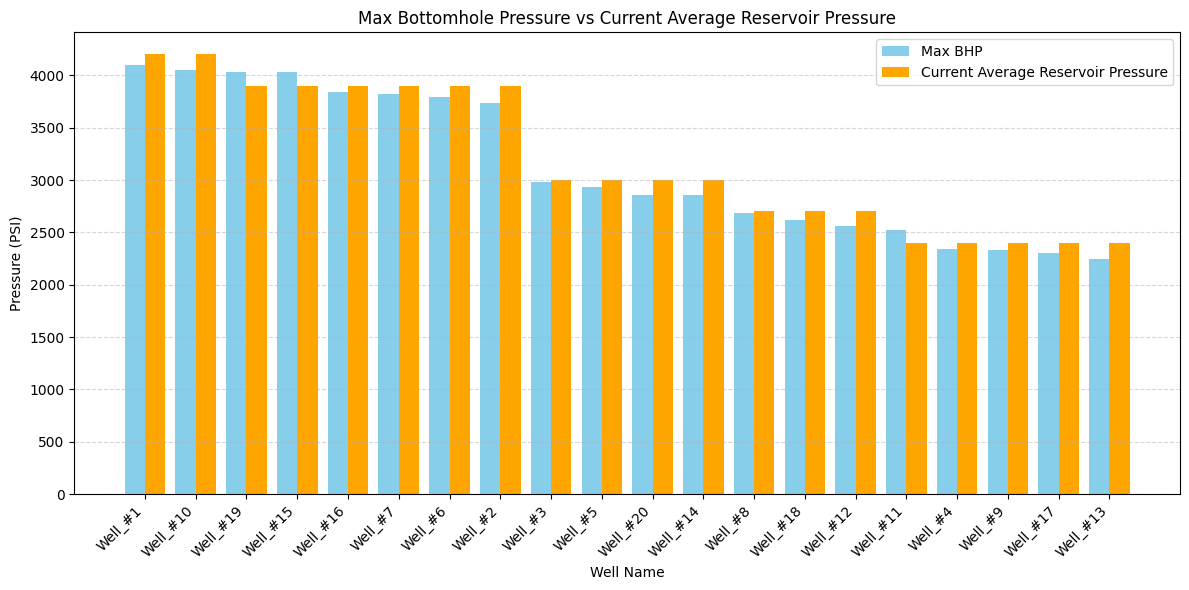

In [10]:
merged_df = classification_df.merge(
    reservoir_info[['Reservoir Name', 'Current Average Reservoir Pressure (PSI)']],
    how='left',
    left_on='Reservoir_Name',
    right_on='Reservoir Name'
)

# Sort for cleaner plot
merged_df = merged_df.sort_values(by='Max_BHP', ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
bar_width = 0.4
x = range(len(merged_df))

# Plot Max BHP
plt.bar(x, merged_df['Max_BHP'], width=bar_width, label='Max BHP', color='skyblue')

# Plot Initial Reservoir Pressure (overlay bars)
plt.bar(
    [i + bar_width for i in x],
    merged_df['Current Average Reservoir Pressure (PSI)'],
    width=bar_width,
    label='Current Average Reservoir Pressure',
    color='orange'
)

# Add well names as x-tick labels
plt.xticks([i + bar_width / 2 for i in x], merged_df['Well_Name'], rotation=45, ha='right')

# Labels and title
plt.xlabel('Well Name')
plt.ylabel('Pressure (PSI)')
plt.title('Max Bottomhole Pressure vs Current Average Reservoir Pressure')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


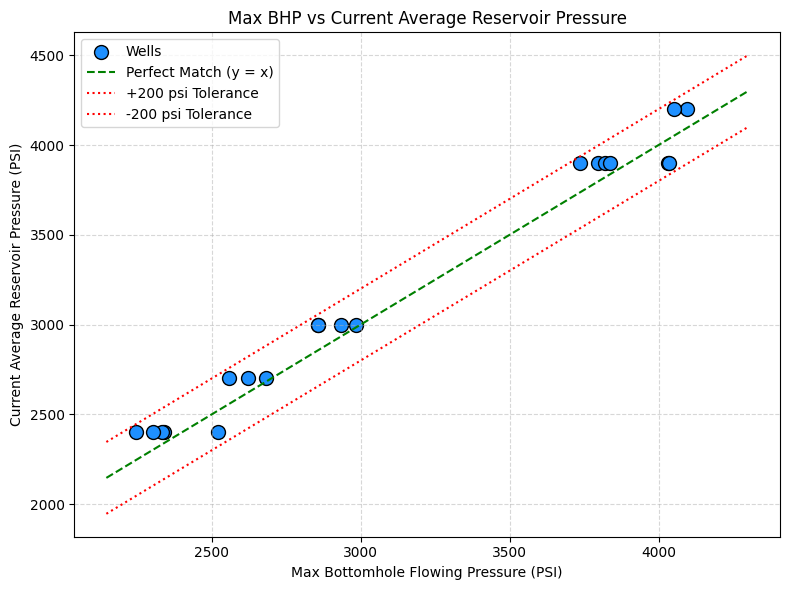

In [11]:
# Merge classification data with reservoir info
scatter_df = classification_df.merge(
    reservoir_info[['Reservoir Name', 'Current Average Reservoir Pressure (PSI)']],
    how='left',
    left_on='Reservoir_Name',
    right_on='Reservoir Name'
)

# Plot
plt.figure(figsize=(8, 6))

# Scatter points
plt.scatter(
    scatter_df['Max_BHP'],
    scatter_df['Current Average Reservoir Pressure (PSI)'],
    c='dodgerblue',
    edgecolor='black',
    s=100,
    label='Wells'
)

# Diagonal line (perfect match line)
min_val = min(scatter_df['Max_BHP'].min(), scatter_df['Current Average Reservoir Pressure (PSI)'].min()) - 100
max_val = max(scatter_df['Max_BHP'].max(), scatter_df['Current Average Reservoir Pressure (PSI)'].max()) + 100

plt.plot([min_val, max_val], [min_val, max_val], color='green', linestyle='--', label='Perfect Match (y = x)')

# Upper and lower bounds (+/- 200 psi)
plt.plot([min_val, max_val], [min_val + 200, max_val + 200], color='red', linestyle=':', label='+200 psi Tolerance')
plt.plot([min_val, max_val], [min_val - 200, max_val - 200], color='red', linestyle=':', label='-200 psi Tolerance')

# Labels and title
plt.xlabel('Max Bottomhole Flowing Pressure (PSI)')
plt.ylabel('Current Average Reservoir Pressure (PSI)')
plt.title('Max BHP vs Current Average Reservoir Pressure')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


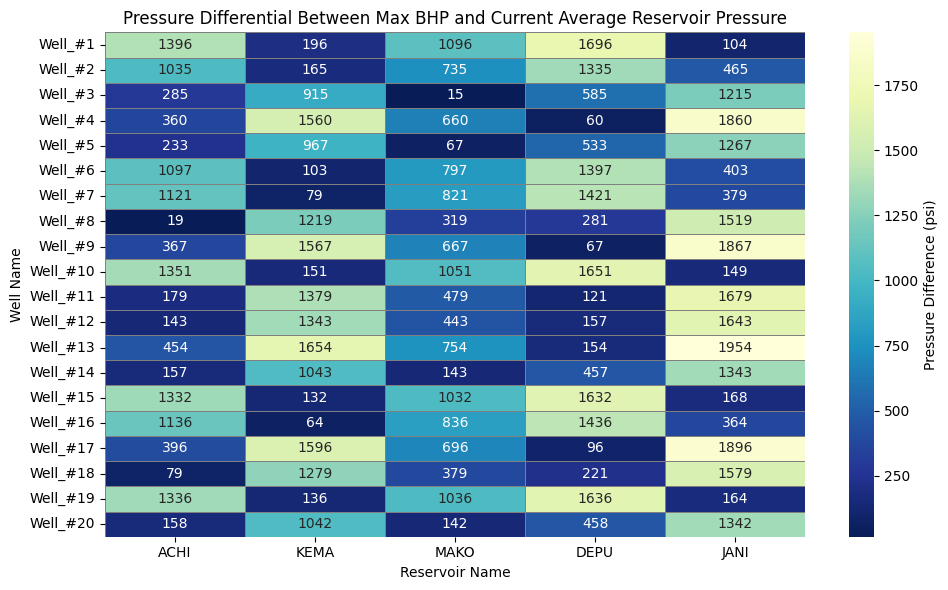

In [12]:
# Create a dictionary to store pressure differentials
pressure_diff_matrix = {}

# Loop through each well
for well in classification_df['Well_Name']:
    # Get max BHP for this well
    max_bhp = classification_df[classification_df['Well_Name'] == well]['Max_BHP'].values[0]
    
    # Calculate pressure difference for each reservoir
    diffs = {}
    for _, row in reservoir_info.iterrows():
        reservoir_name = row['Reservoir Name']
        reservoir_pressure = row['Current Average Reservoir Pressure (PSI)']
        diff = abs(max_bhp - reservoir_pressure)
        diffs[reservoir_name] = diff
    
    pressure_diff_matrix[well] = diffs

# Convert to DataFrame
pressure_diff_df = pd.DataFrame.from_dict(pressure_diff_matrix, orient='index')

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    pressure_diff_df,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu_r",  # Inverted green-blue color map: green = lower, blue = higher
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Pressure Difference (psi)'}
)

plt.title("Pressure Differential Between Max BHP and Current Average Reservoir Pressure")
plt.xlabel("Reservoir Name")
plt.ylabel("Well Name")
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

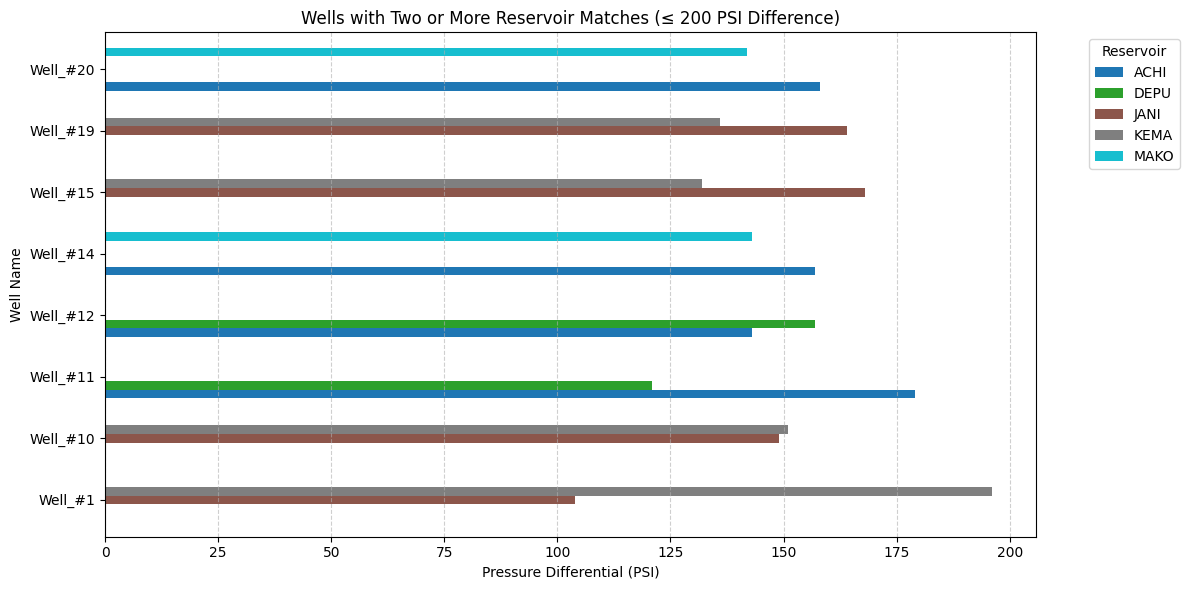

In [13]:
# Step 1: Create a list to store wells with multiple potential matches
multi_match_records = []

# Loop through each well to find multiple matches
for well in classification_df['Well_Name']:
    max_bhp = classification_df[classification_df['Well_Name'] == well]['Max_BHP'].values[0]
    
    # Loop through reservoirs and check which are within 200 psi
    matches = []
    for _, res_row in reservoir_info.iterrows():
        res_name = res_row['Reservoir Name']
        init_pressure = res_row['Current Average Reservoir Pressure (PSI)']
        diff = abs(max_bhp - init_pressure)
        
        if diff <= 200:
            matches.append((res_name, diff))
    
    # Only include wells with 2 or more matching reservoirs
    if len(matches) >= 2:
        for match in matches:
            multi_match_records.append({
                'Well_Name': well,
                'Reservoir_Name': match[0],
                'Pressure_Diff': match[1]
            })

# Convert to DataFrame
multi_match_df = pd.DataFrame(multi_match_records)

if multi_match_df.empty:
    print("No wells have two or more potential reservoirs within 200 psi.")
else:
    # Step 2: Create visualization
    plt.figure(figsize=(12, 6))

    # Pivot data for plotting
    pivot_df = multi_match_df.pivot(index='Well_Name', columns='Reservoir_Name', values='Pressure_Diff')

    # Plot as horizontal bar chart
    pivot_df.plot(kind='barh', figsize=(12, 6), colormap='tab10', width=0.7)

    plt.xlabel("Pressure Differential (PSI)")
    plt.ylabel("Well Name")
    plt.title("Wells with Two or More Reservoir Matches (≤ 200 PSI Difference)")
    plt.legend(title="Reservoir", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


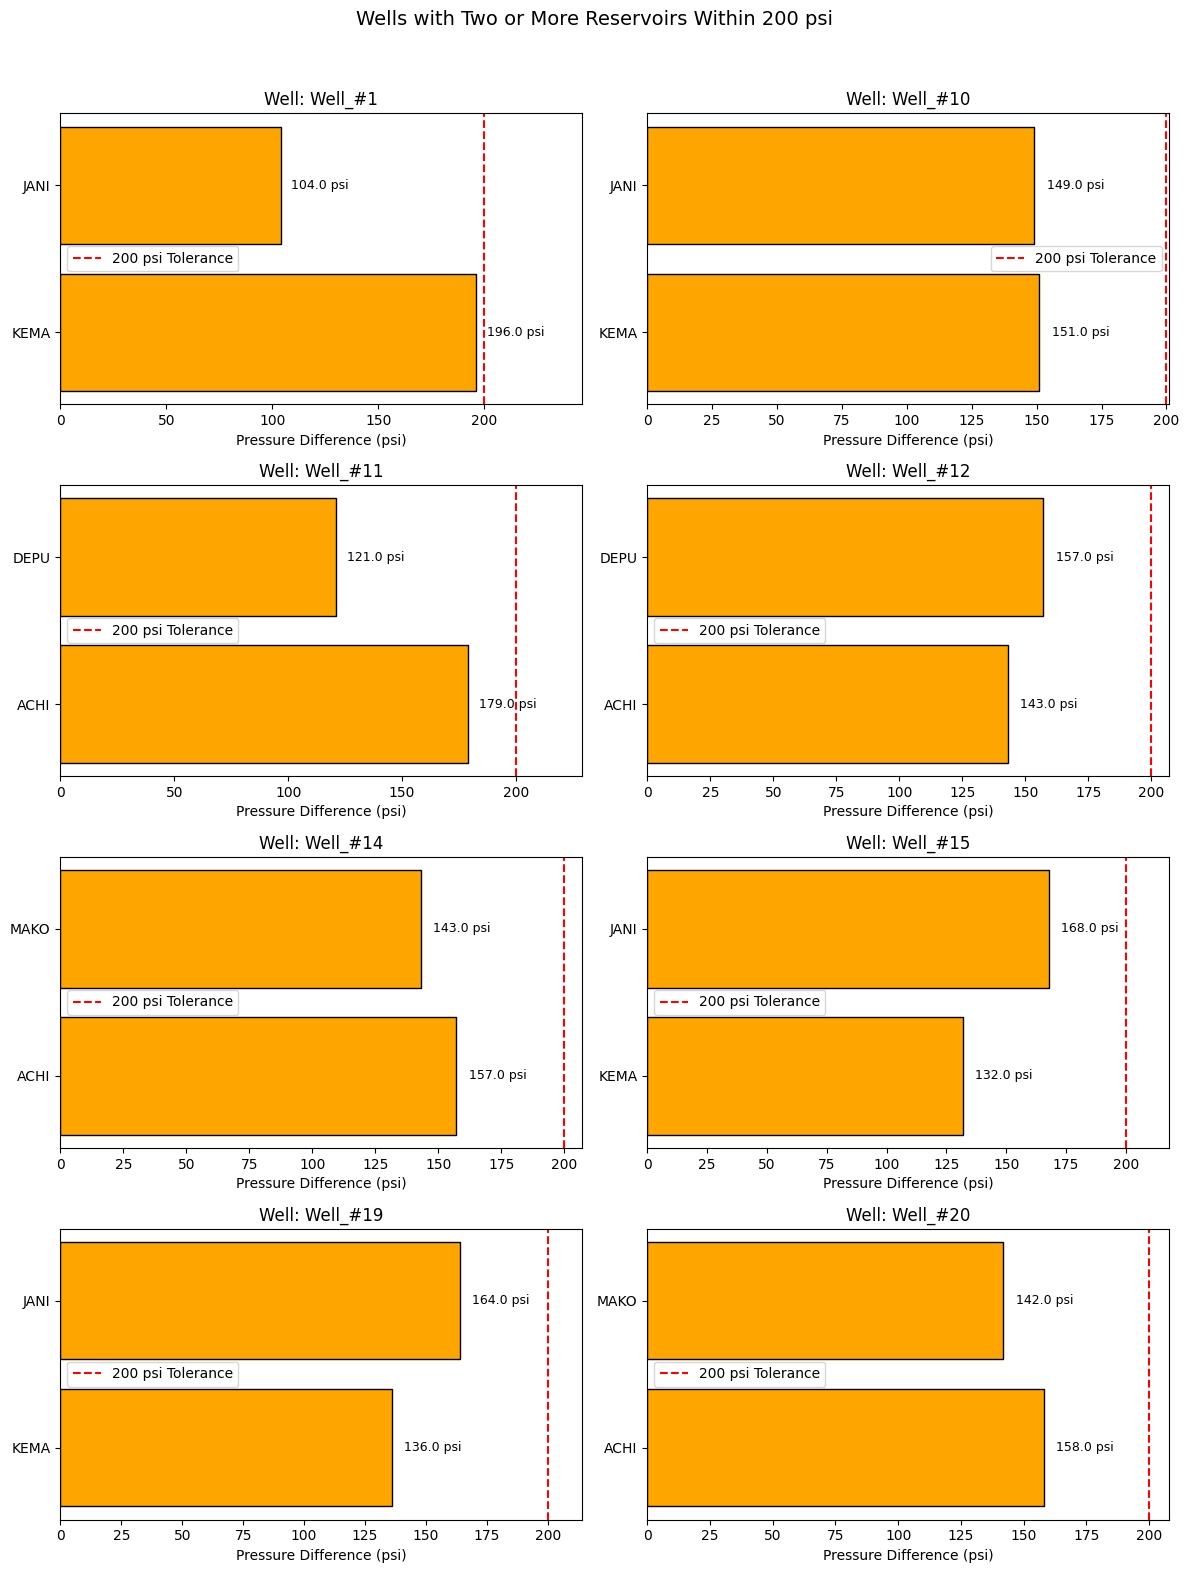

In [14]:
import matplotlib.pyplot as plt
import math

# Threshold for pressure difference
tolerance = 200

# Store wells with multiple matches
multi_match_wells = {}

# Identify wells with 2 or more reservoir matches
for well in classification_df['Well_Name']:
    max_bhp = classification_df[classification_df['Well_Name'] == well]['Max_BHP'].values[0]
    matches = []

    for _, row in reservoir_info.iterrows():
        reservoir = row['Reservoir Name']
        init_pressure = row['Current Average Reservoir Pressure (PSI)']
        diff = abs(max_bhp - init_pressure)
        if diff <= tolerance:
            matches.append((reservoir, diff))

    if len(matches) >= 2:
        multi_match_wells[well] = matches

# Plot subplots if there are any multi-match wells
if not multi_match_wells:
    print("No wells have two or more potential reservoir matches within ±200 psi.")
else:
    num_wells = len(multi_match_wells)
    cols = 2
    rows = math.ceil(num_wells / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten()

    for idx, (well, matches) in enumerate(multi_match_wells.items()):
        reservoirs = [m[0] for m in matches]
        diffs = [m[1] for m in matches]

        ax = axes[idx]
        bars = ax.barh(reservoirs, diffs, color='orange', edgecolor='black')

        for bar, diff in zip(bars, diffs):
            ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                    f'{diff:.1f} psi', va='center', fontsize=9)

        ax.set_title(f'Well: {well}', fontsize=12)
        ax.set_xlabel('Pressure Difference (psi)')
        ax.axvline(x=200, color='red', linestyle='--', label='200 psi Tolerance')
        ax.set_xlim(0, max(diffs) + 50)
        ax.legend()

    # Hide any unused subplots
    for i in range(idx + 1, len(axes)):
        fig.delaxes(axes[i])
    fig.suptitle('Wells with Two or More Reservoirs Within 200 psi', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [15]:
# Create dictionary to store classification for each well
single_match_labels = {}

In [16]:
# Loop through unique wells
for well in well_data['WELL_NAME'].unique():
    # Get Max BHP for this well
    max_bhp = well_data[well_data['WELL_NAME'] == well]['BOTTOMHOLE_FLOWING_PRESSURE (PSI)'].max()
    
    # Calculate pressure difference with each reservoir
    matches = []
    for _, res in reservoir_info.iterrows():
        reservoir = res['Reservoir Name']
        avg_pressure = res['Current Average Reservoir Pressure (PSI)']
        diff = abs(max_bhp - avg_pressure)
        
        if diff <= 200:
            matches.append(reservoir)
    
    # If only one match, record it
    if len(matches) == 1:
        single_match_labels[well] = matches[0]

In [17]:

# Add new column to original dataset
well_data['RESERVOIR_CLASSIFICATION'] = well_data['WELL_NAME'].map(single_match_labels)

In [18]:
well_data.head(3)

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL),RESERVOIR_CLASSIFICATION
0,2014-02-15,Well_#1,0.0,4050,189.866,0.0,1.17951,482.460,50.864,0,0,0,0,NaN
1,2014-02-16,Well_#1,0.0,3961,189.945,0.0,2.99440,328.601,47.668,0,0,0,0,NaN
2,2014-02-17,Well_#1,0.0,3961,190.004,0.0,1.90349,387.218,48.962,0,0,0,0,NaN


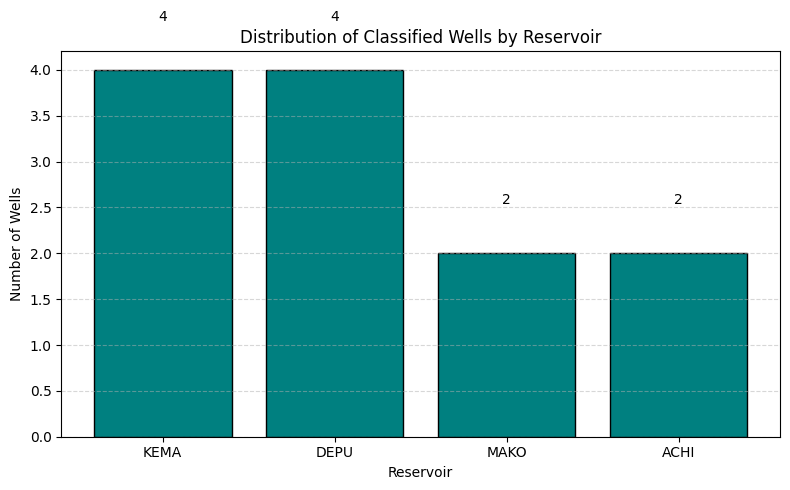

In [19]:
import matplotlib.pyplot as plt

# Count how many wells have been classified into each reservoir
reservoir_counts = well_data.drop_duplicates(subset=['WELL_NAME', 'RESERVOIR_CLASSIFICATION'])
reservoir_counts = reservoir_counts['RESERVOIR_CLASSIFICATION'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(reservoir_counts.index, reservoir_counts.values, color='teal', edgecolor='black')

# Annotate bars with count values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom')

plt.title('Distribution of Classified Wells by Reservoir')
plt.xlabel('Reservoir')
plt.ylabel('Number of Wells')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


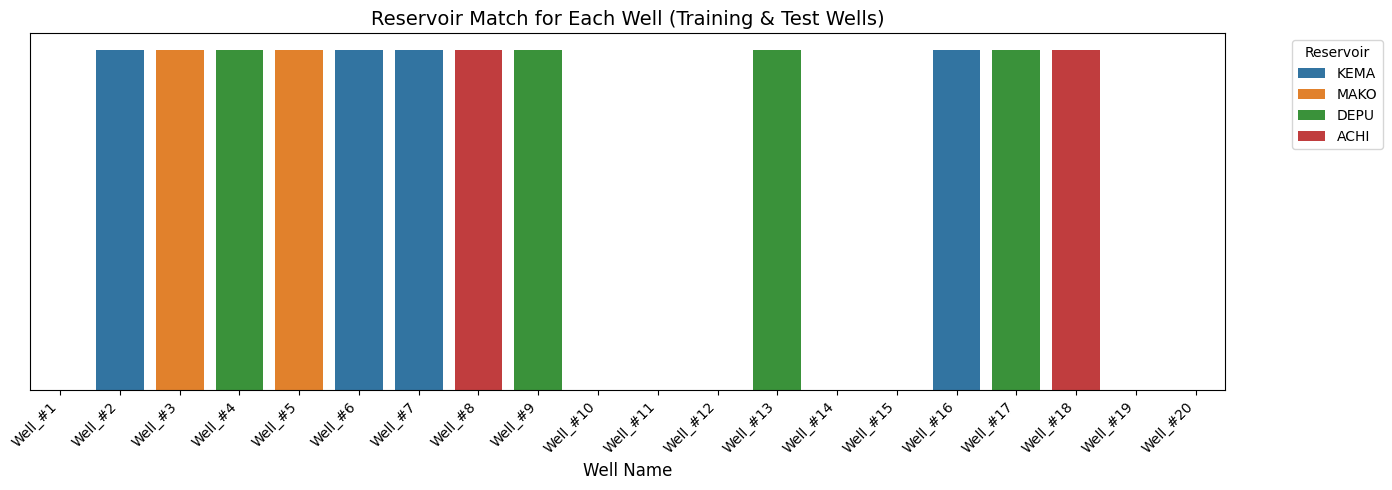

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import re

# Extract one row per well (latest classification or NaN)
well_res_match = well_data.groupby('WELL_NAME')['RESERVOIR_CLASSIFICATION'].first().reset_index()

# Extract numeric part of WELL_NAME for sorting (e.g., Well_#9 → 9)
well_res_match['WELL_NUM'] = well_res_match['WELL_NAME'].apply(lambda x: int(re.search(r'\d+', x).group()))

# Sort by WELL_NUM
well_res_match = well_res_match.sort_values('WELL_NUM')

# Plot
plt.figure(figsize=(14, 5))
sns.barplot(
    data=well_res_match,
    x='WELL_NAME',
    y=[1]*len(well_res_match),  # Dummy height
    hue='RESERVOIR_CLASSIFICATION',
    dodge=False,
    palette='tab10'
)

# Styling
plt.title('Reservoir Match for Each Well (Training & Test Wells)', fontsize=14)
plt.ylabel('')
plt.yticks([])
plt.xlabel('Well Name', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Reservoir', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [21]:
# Get reservoir reference values
jani_pressure = reservoir_info[reservoir_info['Reservoir Name'] == 'JANI']['Current Average Reservoir Pressure (PSI)'].values[0]
jani_gor = reservoir_info[reservoir_info['Reservoir Name'] == 'JANI']['Solution Gas-Oil-Ratio (SCF/BBL)'].values[0]

kema_pressure = reservoir_info[reservoir_info['Reservoir Name'] == 'KEMA']['Current Average Reservoir Pressure (PSI)'].values[0]
kema_gor = reservoir_info[reservoir_info['Reservoir Name'] == 'KEMA']['Solution Gas-Oil-Ratio (SCF/BBL)'].values[0]

# Identify candidate wells with both JANI and KEMA as possible matches
jani_kema_candidates = {
    well: matches
    for well, matches in multi_match_wells.items()
    if set([r[0] for r in matches]) >= set(['JANI', 'KEMA'])
}

# Prepare data
comparison_data = []

for well in jani_kema_candidates:
    well_subset = well_data[well_data['WELL_NAME'] == well]
    
    max_bhp = well_subset['BOTTOMHOLE_FLOWING_PRESSURE (PSI)'].max()
    
    # Estimate actual GOR
    cum_oil = well_subset['CUMULATIVE_OIL_PROD (STB)'].max()
    cum_gas = well_subset['CUMULATIVE_FORMATION_GAS_PROD (MSCF)'].max()
    
    actual_gor = (cum_gas * 1000) / cum_oil if cum_oil > 0 else 0
    
    comparison_data.append({
        'Well': well,
        'Max_BHP': max_bhp,
        'Actual_GOR': actual_gor
    })

# Convert to DataFrame
comp_df = pd.DataFrame(comparison_data)

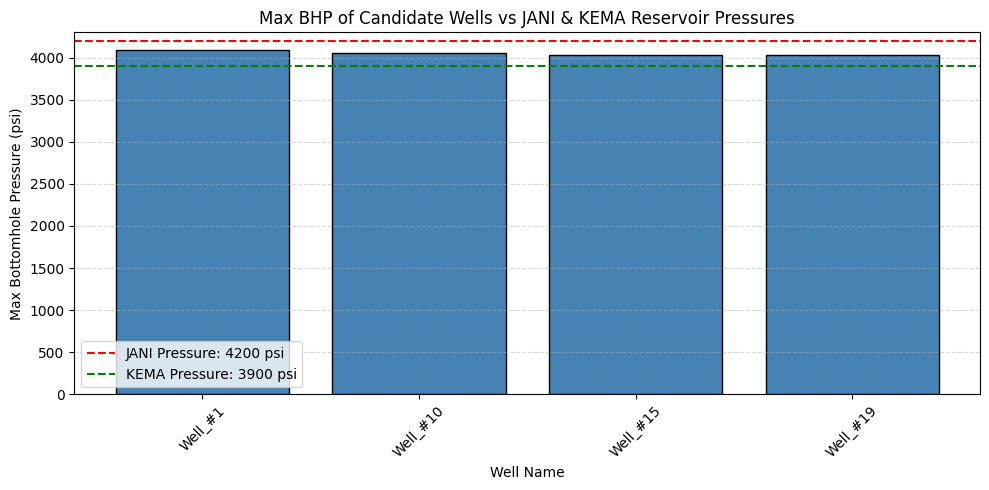

In [22]:
# ----------- PLOT: Max BHP vs JANI & KEMA Pressure -----------
plt.figure(figsize=(10, 5))
bars = plt.bar(comp_df['Well'], comp_df['Max_BHP'], color='steelblue', edgecolor='black')
plt.axhline(jani_pressure, color='red', linestyle='--', label=f'JANI Pressure: {jani_pressure} psi')
plt.axhline(kema_pressure, color='green', linestyle='--', label=f'KEMA Pressure: {kema_pressure} psi')
plt.title('Max BHP of Candidate Wells vs JANI & KEMA Reservoir Pressures')
plt.ylabel('Max Bottomhole Pressure (psi)')
plt.xlabel('Well Name')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

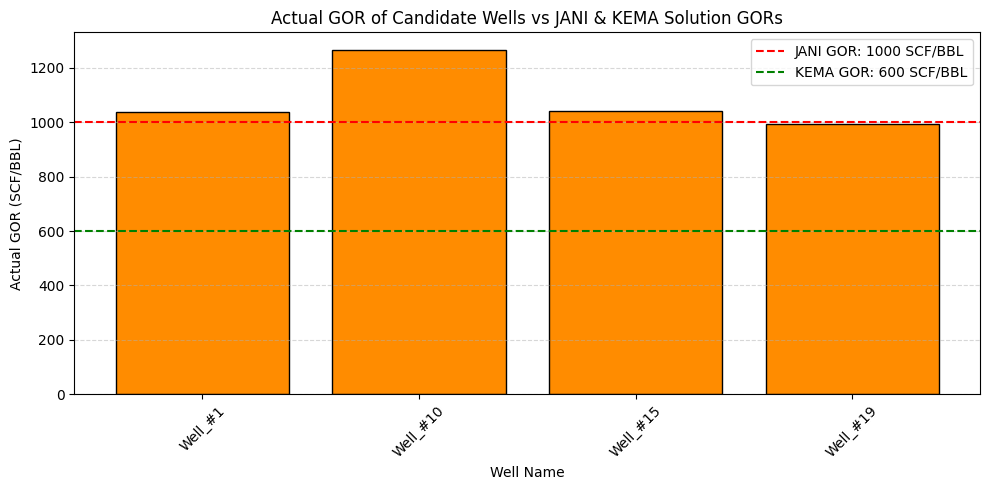

In [23]:
# ----------- PLOT: Actual GOR vs JANI & KEMA GOR -----------
plt.figure(figsize=(10, 5))
bars = plt.bar(comp_df['Well'], comp_df['Actual_GOR'], color='darkorange', edgecolor='black')
plt.axhline(jani_gor, color='red', linestyle='--', label=f'JANI GOR: {jani_gor} SCF/BBL')
plt.axhline(kema_gor, color='green', linestyle='--', label=f'KEMA GOR: {kema_gor} SCF/BBL')
plt.title('Actual GOR of Candidate Wells vs JANI & KEMA Solution GORs')
plt.ylabel('Actual GOR (SCF/BBL)')
plt.xlabel('Well Name')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [24]:
# Step 1: Extract wells confidently assigned to KEMA (train set)
kema_train_wells = well_data[
    well_data['RESERVOIR_CLASSIFICATION'] == 'KEMA'
]['WELL_NAME'].unique()

# Step 2: Extract candidate wells where both JANI and KEMA are possible
kema_jani_candidates = [
    well for well, matches in multi_match_wells.items()
    if set([m[0] for m in matches]) >= set(['KEMA', 'JANI'])
]

# Step 3: Function to calculate Max BHP and Actual GOR
def summarize_wells(well_list, label):
    records = []
    for well in well_list:
        well_subset = well_data[well_data['WELL_NAME'] == well]
        max_bhp = well_subset['BOTTOMHOLE_FLOWING_PRESSURE (PSI)'].max()
        cum_oil = well_subset['CUMULATIVE_OIL_PROD (STB)'].max()
        cum_gas = well_subset['CUMULATIVE_FORMATION_GAS_PROD (MSCF)'].max()
        gor = (cum_gas * 1000) / cum_oil if cum_oil > 0 else 0

        records.append({
            'Well': well,
            'Max_BHP': max_bhp,
            'Actual_GOR': gor,
            'Group': label
        })
    return records

# Step 4: Combine both groups into a single DataFrame
train_kema_summary = summarize_wells(kema_train_wells, 'Confirmed KEMA')
candidate_summary = summarize_wells(kema_jani_candidates, 'Candidate')

compare_df = pd.DataFrame(train_kema_summary + candidate_summary)



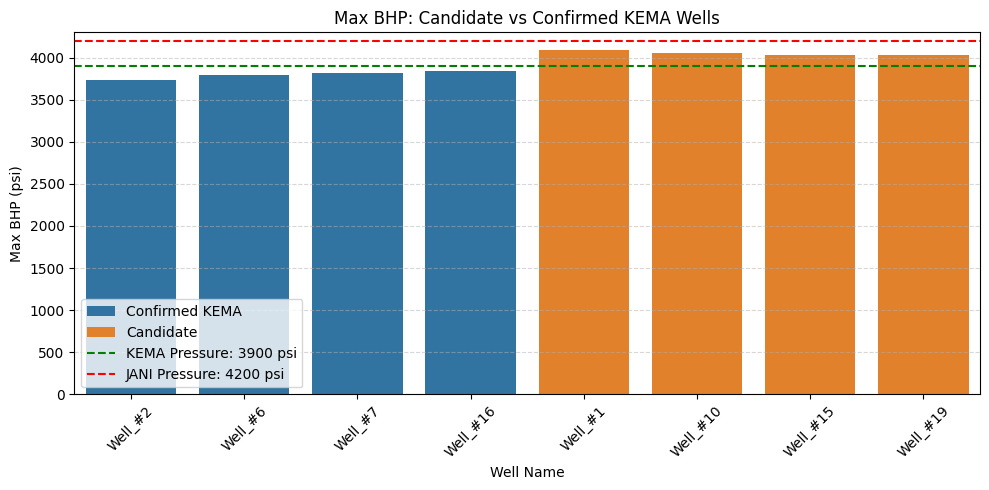

In [25]:
# Step 5: Plot — Max BHP
plt.figure(figsize=(10, 5))
sns.barplot(data=compare_df, x='Well', y='Max_BHP', hue='Group', dodge=False)
plt.axhline(kema_pressure, color='green', linestyle='--', label=f'KEMA Pressure: {kema_pressure} psi')
plt.axhline(jani_pressure, color='red', linestyle='--', label=f'JANI Pressure: {jani_pressure} psi')
plt.title('Max BHP: Candidate vs Confirmed KEMA Wells')
plt.ylabel('Max BHP (psi)')
plt.xlabel('Well Name')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

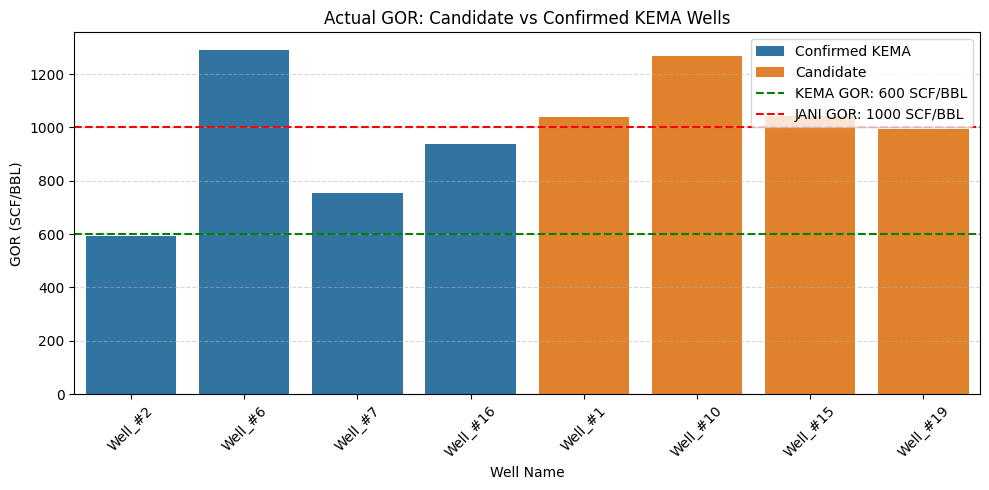

In [26]:
# Step 6: Plot — Actual GOR
plt.figure(figsize=(10, 5))
sns.barplot(data=compare_df, x='Well', y='Actual_GOR', hue='Group', dodge=False)
plt.axhline(kema_gor, color='green', linestyle='--', label=f'KEMA GOR: {kema_gor} SCF/BBL')
plt.axhline(jani_gor, color='red', linestyle='--', label=f'JANI GOR: {jani_gor} SCF/BBL')
plt.title('Actual GOR: Candidate vs Confirmed KEMA Wells')
plt.ylabel('GOR (SCF/BBL)')
plt.xlabel('Well Name')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [27]:
well_data.head(3)

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL),RESERVOIR_CLASSIFICATION
0,2014-02-15,Well_#1,0.0,4050,189.866,0.0,1.17951,482.460,50.864,0,0,0,0,NaN
1,2014-02-16,Well_#1,0.0,3961,189.945,0.0,2.99440,328.601,47.668,0,0,0,0,NaN
2,2014-02-17,Well_#1,0.0,3961,190.004,0.0,1.90349,387.218,48.962,0,0,0,0,NaN


In [28]:
well_data.nunique()

PROD_DATE                               2004
WELL_NAME                                 20
ON_STREAM_HRS                            445
BOTTOMHOLE_FLOWING_PRESSURE (PSI)       2052
DOWNHOLE_TEMPERATURE (deg F)            5573
ANNULUS_PRESS (PSI)                     5216
CHOKE_SIZE (%)                          5038
WELL_HEAD_PRESSURE (PSI)                7113
WELL_HEAD_TEMPERATURE (deg F)           6527
CUMULATIVE_OIL_PROD (STB)               7053
CUMULATIVE_FORMATION_GAS_PROD (MSCF)    7033
CUMULATIVE_TOTAL_GAS_PROD (MSCF)        7040
CUMULATIVE_WATER_PROD (BBL)             6775
RESERVOIR_CLASSIFICATION                   4
dtype: int64

In [29]:
# # Replace 'Well_#10' with the actual well name or ID if different
# well_data.loc[well_data['WELL_NAME'] == 'Well_#1', 'RESERVOIR_CLASSIFICATION'] = 'JANI'

In [30]:
well_data['RESERVOIR_CLASSIFICATION'].unique()

array([nan, 'KEMA', 'MAKO', 'DEPU', 'ACHI'], dtype=object)

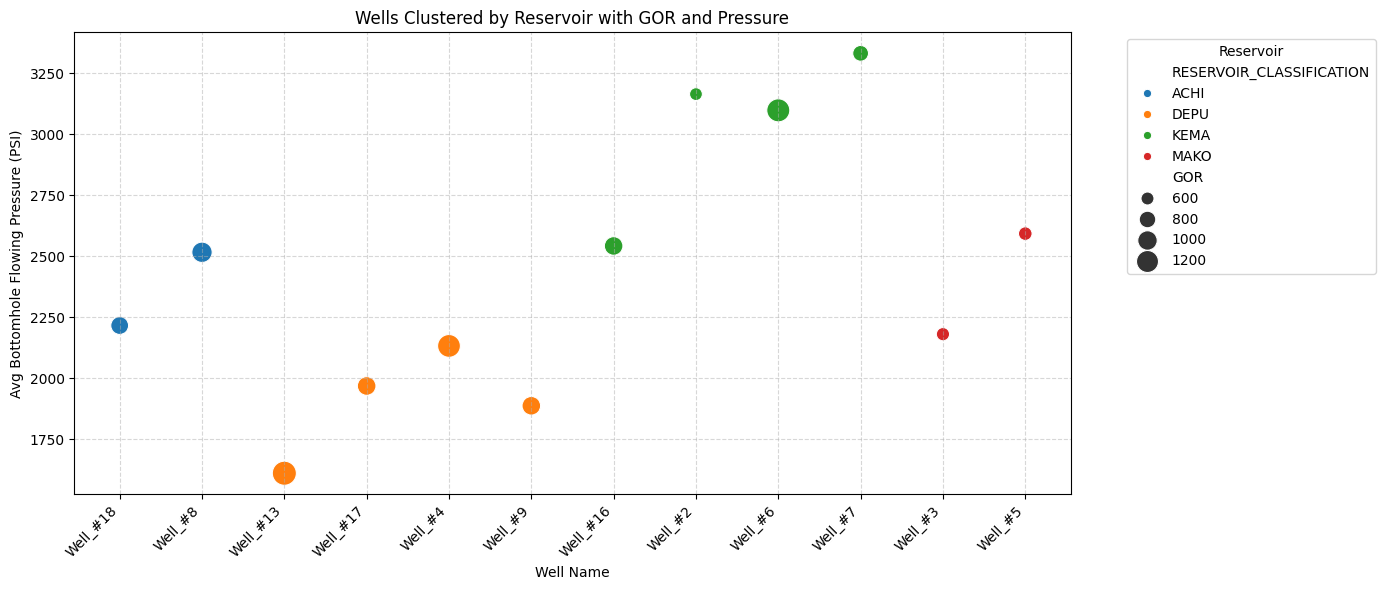

In [31]:
# Prepare summarized data per well
well_summary = well_data.groupby('WELL_NAME').agg({
    'BOTTOMHOLE_FLOWING_PRESSURE (PSI)': 'mean',
    'CUMULATIVE_FORMATION_GAS_PROD (MSCF)': 'max',
    'CUMULATIVE_OIL_PROD (STB)': 'max',
    'RESERVOIR_CLASSIFICATION': 'first'  # assuming constant per well
}).reset_index()

# Calculate GOR (in SCF/BBL)
well_summary['GOR'] = (well_summary['CUMULATIVE_FORMATION_GAS_PROD (MSCF)'] * 1000) / well_summary['CUMULATIVE_OIL_PROD (STB)']
well_summary['GOR'] = well_summary['GOR'].replace([float('inf'), -float('inf')], None)  # clean inf
well_summary.dropna(subset=['GOR'], inplace=True)

# Sort by reservoir for cluster-like separation
well_summary = well_summary.sort_values('RESERVOIR_CLASSIFICATION')

# Plot
plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=well_summary,
    x='WELL_NAME',
    y='BOTTOMHOLE_FLOWING_PRESSURE (PSI)',
    size='GOR',
    hue='RESERVOIR_CLASSIFICATION',
    palette='tab10',
    sizes=(40, 300),
    legend='brief'
)

# Customize
plt.title('Wells Clustered by Reservoir with GOR and Pressure')
plt.xlabel('Well Name')
plt.ylabel('Avg Bottomhole Flowing Pressure (PSI)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Reservoir')
plt.tight_layout()

plt.show()


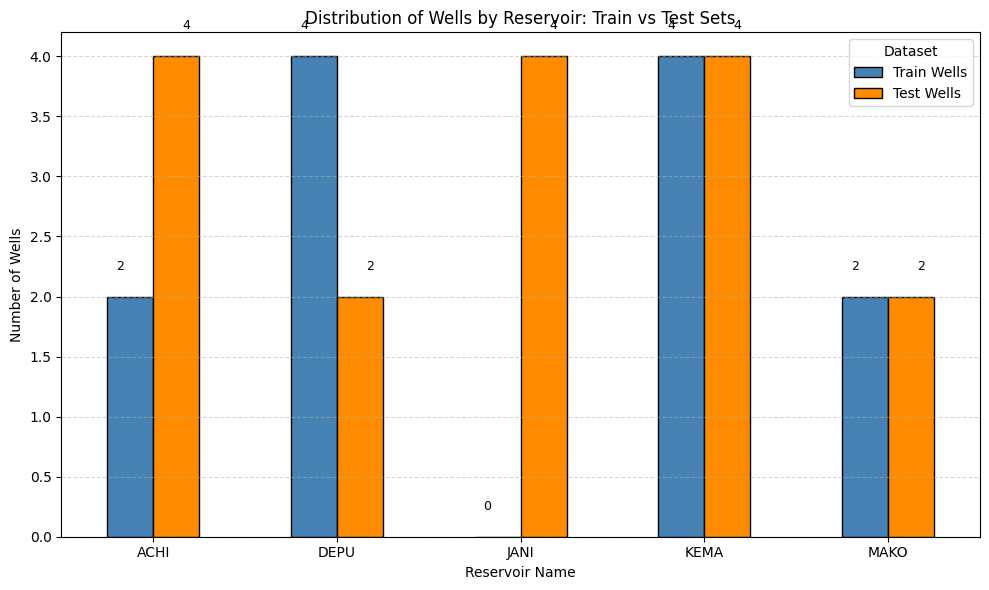

In [32]:
# --------------------------
# TRAINING SET DISTRIBUTION
# --------------------------
# Get unique wells and their assigned reservoir
train_well_labels = (
    well_data[well_data['RESERVOIR_CLASSIFICATION'].notna()]
    .groupby('WELL_NAME')['RESERVOIR_CLASSIFICATION']
    .first()
)

train_counts = train_well_labels.value_counts()

# --------------------------
# TEST SET DISTRIBUTION
# --------------------------
# Create a flat list of potential reservoirs from the 8 ambiguous wells
test_reservoirs = []
for well, matches in multi_match_wells.items():
    if well not in train_well_labels:  # exclude manually labeled wells
        test_reservoirs.extend([r[0] for r in matches])

test_counts = pd.Series(test_reservoirs).value_counts()

# Combine into a single DataFrame
all_reservoirs = sorted(set(train_counts.index).union(set(test_counts.index)))

compare_df = pd.DataFrame({
    'Train Wells': train_counts.reindex(all_reservoirs, fill_value=0),
    'Test Wells': test_counts.reindex(all_reservoirs, fill_value=0)
})

# --------------------------
# PLOT WITH COUNTS
# --------------------------
ax = compare_df.plot(
    kind='bar',
    figsize=(10, 6),
    color=['steelblue', 'darkorange'],
    edgecolor='black'
)

plt.title('Distribution of Wells by Reservoir: Train vs Test Sets')
plt.xlabel('Reservoir Name')
plt.ylabel('Number of Wells')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Dataset')

# Add counts above bars
for i, reservoir in enumerate(compare_df.index):
    train_val = compare_df.loc[reservoir, 'Train Wells']
    test_val = compare_df.loc[reservoir, 'Test Wells']
    
    ax.text(i - 0.18, train_val + 0.2, str(train_val), ha='center', va='bottom', fontsize=9)
    ax.text(i + 0.18, test_val + 0.2, str(test_val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


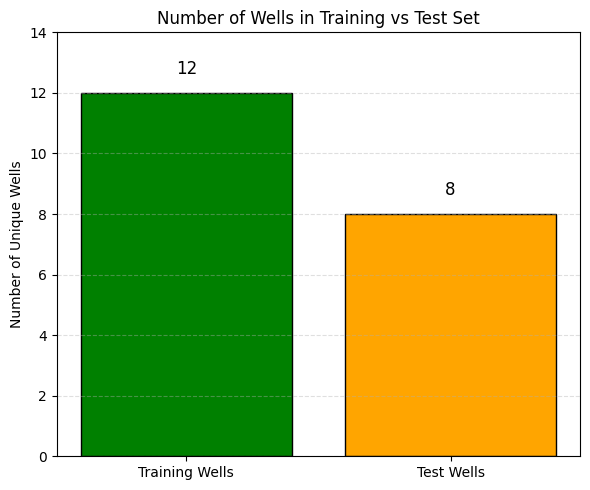

In [33]:
# Step 1: Count unique wells in training and test sets
train_wells = well_data[well_data['RESERVOIR_CLASSIFICATION'].notna()]['WELL_NAME'].unique()
test_wells = well_data[well_data['RESERVOIR_CLASSIFICATION'].isna()]['WELL_NAME'].unique()

counts = {
    'Training Wells': len(train_wells),
    'Test Wells': len(test_wells)
}

# Step 2: Plot
plt.figure(figsize=(6, 5))
bars = plt.bar(counts.keys(), counts.values(), color=['green', 'orange'], edgecolor='black')

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(height), ha='center', va='bottom', fontsize=12)

# Labels and style
plt.title('Number of Wells in Training vs Test Set')
plt.ylabel('Number of Unique Wells')
plt.ylim(0, max(counts.values()) + 2)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [34]:
# Training Set: Rows with a valid reservoir classification
training_df = well_data[well_data['RESERVOIR_CLASSIFICATION'].notnull()].copy()

# Test Set: Rows without a classification label
test_df = well_data[well_data['RESERVOIR_CLASSIFICATION'].isnull()].copy()

In [35]:
# Show summary
print(f"Training set size: {training_df.shape}")
print(f"Test set size: {test_df.shape}")

Training set size: (4634, 14)
Test set size: (3321, 14)


In [36]:
training_df.sample(5)

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL),RESERVOIR_CLASSIFICATION
2829,2012-03-29,Well_#8,24.0,2568,143.925,811.814,99.94437,58.292,98.534,198792,208245,333514,189041,ACHI
6239,2014-10-29,Well_#17,24.0,2198,154.926,949.301,35.19035,114.837,81.614,72506,66387,95892,67333,DEPU
5276,2013-03-15,Well_#13,24.0,1575,106.621,16.017,11.61428,44.010,29.799,132675,181166,181166,26526,DEPU
2239,2012-05-26,Well_#7,24.0,3622,202.205,762.915,31.88837,488.442,87.728,313925,229214,344213,282547,KEMA
6397,2015-04-05,Well_#17,24.0,1895,156.212,727.705,100.00000,66.821,88.776,186737,172354,248956,228348,DEPU


In [37]:
training_df.nunique()

PROD_DATE                               2003
WELL_NAME                                 12
ON_STREAM_HRS                            271
BOTTOMHOLE_FLOWING_PRESSURE (PSI)       1600
DOWNHOLE_TEMPERATURE (deg F)            3195
ANNULUS_PRESS (PSI)                     3033
CHOKE_SIZE (%)                          2963
WELL_HEAD_PRESSURE (PSI)                4108
WELL_HEAD_TEMPERATURE (deg F)           3974
CUMULATIVE_OIL_PROD (STB)               3936
CUMULATIVE_FORMATION_GAS_PROD (MSCF)    3941
CUMULATIVE_TOTAL_GAS_PROD (MSCF)        3940
CUMULATIVE_WATER_PROD (BBL)             3817
RESERVOIR_CLASSIFICATION                   4
dtype: int64

In [38]:
test_df.sample(5)

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL),RESERVOIR_CLASSIFICATION
5082,2013-09-15,Well_#12,24.0,2104,159.510,0.000,46.88428,80.330,86.822,575682,390240,390240,317924,NaN
7210,2013-03-26,Well_#20,24.0,2285,152.000,1161.020,75.32041,121.096,88.421,81983,44254,66382,45211,NaN
4191,2012-05-03,Well_#11,24.0,2459,143.489,850.461,96.86312,141.904,77.741,114093,128738,167360,44205,NaN
6964,2014-06-23,Well_#19,24.0,3877,158.609,0.000,100.00000,101.866,90.239,43801,42983,42983,16319,NaN
5,2014-02-20,Well_#1,0.0,3964,190.181,0.000,0.00000,58.036,47.878,0,0,0,0,NaN


In [39]:
test_df.nunique()

PROD_DATE                               1554
WELL_NAME                                  8
ON_STREAM_HRS                            275
BOTTOMHOLE_FLOWING_PRESSURE (PSI)       1059
DOWNHOLE_TEMPERATURE (deg F)            2734
ANNULUS_PRESS (PSI)                     2229
CHOKE_SIZE (%)                          2254
WELL_HEAD_PRESSURE (PSI)                3032
WELL_HEAD_TEMPERATURE (deg F)           2960
CUMULATIVE_OIL_PROD (STB)               3141
CUMULATIVE_FORMATION_GAS_PROD (MSCF)    3136
CUMULATIVE_TOTAL_GAS_PROD (MSCF)        3136
CUMULATIVE_WATER_PROD (BBL)             3038
RESERVOIR_CLASSIFICATION                   0
dtype: int64

In [40]:
test_df['RESERVOIR_CLASSIFICATION'].unique()

array([nan], dtype=object)

In [41]:
training_df.to_csv('../notebooks/Models/data/training_data.csv', index=False)

In [42]:
test_df.to_csv('../notebooks/Models/data/test_data.csv', index=False)

In [43]:
# # Merge classification parameters into training_df
# training_df = training_df.merge(
#     reservoir_info,
#     left_on='RESERVOIR_CLASSIFICATION',
#     right_on='Reservoir Name',
#     how='left'
# )

In [44]:
# training_df.head(3)

In [45]:
sample_sub.head()

,Well,Reservoir Name,Reservoir Type,Well Type,Production Type,Formation GOR Trend,Watercut Trend,Oil Productivity Index
0,1,KEMA,Saturated,GL,Unsteady,aSolGOR,Flat,Decr
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
reservoir_info['Saturation_Status'] = reservoir_info.apply(
    lambda row: 'Saturated' if row['Initial Reservoir Pressure (PSI)'] <= row['Bubble Point Pressure (PSI)'] else 'Undersaturated',
    axis=1
)

In [47]:
reservoir_info

,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB),Saturation_Status
0,ACHI,3500,3300,2700,800,1.20,Undersaturated
1,KEMA,4200,4000,3900,600,1.45,Undersaturated
2,MAKO,3500,3500,3000,500,1.15,Saturated
3,DEPU,2800,2800,2400,1200,1.37,Saturated
4,JANI,4500,4300,4200,1000,1.30,Undersaturated


In [48]:
# Step 1: Define lift classification function
def classify_lift_type(well_subset):
    # Check how often annulus pressure is > 0
    annulus_nonzero_ratio = (well_subset['ANNULUS_PRESS (PSI)'] > 0).mean()
    
    # Check how often BHP > WHP + 1000
    strong_natural_ratio = (well_subset['BOTTOMHOLE_FLOWING_PRESSURE (PSI)'] > 
                            well_subset['WELL_HEAD_PRESSURE (PSI)'] + 1000).mean()
    
    if annulus_nonzero_ratio > 0.5:
        return 'GL'
    elif annulus_nonzero_ratio < 0.5:
        return 'NF'
    else:
        return 'Unknown'


In [49]:
# Step 2: Classify each well
well_lift_types = {}

for well in well_data['WELL_NAME'].unique():
    well_subset = well_data[well_data['WELL_NAME'] == well]
    lift_type = classify_lift_type(well_subset)
    well_lift_types[well] = lift_type


In [50]:
# Step 3a: Add lift type to well_data
well_data['LIFT_TYPE'] = well_data['WELL_NAME'].map(well_lift_types)

# Step 3b: Aggregate to find dominant lift type per reservoir
reservoir_lift_type = (
    well_data[well_data['LIFT_TYPE'].isin(['GL', 'NF'])]
    .groupby('RESERVOIR_CLASSIFICATION')['LIFT_TYPE']
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index(name='Lift_Type')
)

# Step 3c: Merge with reservoir_info
reservoir_info = reservoir_info.merge(
    reservoir_lift_type,
    left_on='Reservoir Name',
    right_on='RESERVOIR_CLASSIFICATION',
    how='left'
)


In [51]:
reservoir_info

,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB),Saturation_Status,RESERVOIR_CLASSIFICATION,Lift_Type
0,ACHI,3500,3300,2700,800,1.20,Undersaturated,ACHI,GL
1,KEMA,4200,4000,3900,600,1.45,Undersaturated,KEMA,GL
2,MAKO,3500,3500,3000,500,1.15,Saturated,MAKO,GL
3,DEPU,2800,2800,2400,1200,1.37,Saturated,DEPU,GL
4,JANI,4500,4300,4200,1000,1.30,Undersaturated,NaN,NaN
